# LC7 — Cleaning and storing energy time series (self-paced, ~60 min when you read every note)

You have been handed a year of hourly Svedala data — exported carelessly, as real data usually is. By the end of this notebook it is clean, every repair is documented, and it lives in analytical storage. Material from this notebook appears in **Quiz 2**, and Lab 5 uses exactly this working method.

**How to use this notebook:** run the cells top to bottom, one at a time. Every code cell has a short note above it saying what the cell is for and what you should see; the numbers quoted are the ones this file produces, so a different number is worth a pause. Every repair lands in `repairs`, a plain Python list that section 8 reads back.

**The one rule of cleaning:** there is a difference between *fixing an error* and *inventing a measurement*. Every repair below gets a line in a repairs log — the habit that becomes your project's decision log.

### Before you start: opening the notebook on your laptop

Local, not Colab — it reads files from the course repository. From a terminal with your workbook's venv active (the Lab 1 one; it has every package this notebook needs):

```bash
pip install jupyterlab            # once; a tool for you, not a dependency of the toolbox, so it is not in requirements.txt
cd <path to your clone of>/course-material/notebooks
jupyter lab                       # opens in your browser; double-click LC07_cleaning_storage.ipynb
```

Start Jupyter *inside* `notebooks/` — the guard cell below checks that. Shift+Enter runs a cell; go top to bottom, one at a time, and pick the `.venv` Python if Jupyter asks which kernel.

### 0. Setup

`%pip install ...` installs into the notebook's own Python; `--quiet` hides the log. **What you see:** one line, "Note: you may need to restart the kernel…" — it appears even when nothing new was installed, and no restart is needed.

In [1]:
# Install exactly what this notebook uses. numpy comes with pandas but we
# name it: explicit beats implicit, in dependencies too.
%pip install pandas numpy pyarrow duckdb matplotlib --quiet

Note: you may need to restart the kernel to use updated packages.


The guard from LC6 again: `assert` stops here with a clear message if `../data` is missing. **What you see:** nothing — good.

In [2]:
from pathlib import Path
# Guard: this notebook expects to run from the notebooks/ folder of a clone of
# the course repository — the datasets live one level up in ../data/.
# Failing here, early and clearly, beats a confusing FileNotFoundError later.
assert Path("../data").exists(), (
    "Course data folder not found. Clone KTH-EG2140/course-material and open "
    "this notebook from its notebooks/ folder.")

Three things: `pd.read_csv(..., index_col=0, parse_dates=True)` reads the file with its first column as the row index and turns that column into timestamps; `repairs = []` is the empty log every repair will append to; `raw.info()` prints one line per column. **How to read the output:** `8780 entries` is the row count; the `Non-Null Count` per column is how many rows actually hold a value — a zone column at 8648 has 132 holes; `float64` means every column is numbers. Two more things about this output. The index runs `2025-01-01 01:00:00 to 2026-01-01 00:00:00` — a year that starts at one in the morning is the first clue that these timestamps are Swedish local time written without saying so; section 2 fixes that. And the cell takes about ten seconds the first time (parsing 8780 timestamps); it has not hung. Keep the two facts, 8780 and the holes, in mind for section 1.

In [3]:
import numpy as np
import pandas as pd

raw = pd.read_csv("../data/svedala-year/svedala_hourly_dirty.csv",
                  index_col=0, parse_dates=True)
repairs = []            # every decision lands here
raw.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 8780 entries, 2025-01-01 01:00:00 to 2026-01-01 00:00:00
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   ZON_NORR     8648 non-null   float64
 1   ZON_MITT     8649 non-null   float64
 2   ZON_SYDVÄST  8648 non-null   float64
 3   ZON_EXTERN   8649 non-null   float64
 4   total_mw     8780 non-null   float64
 5   temp_north   8780 non-null   float64
 6   temp_mid     8708 non-null   float64
 7   temp_south   8780 non-null   float64
dtypes: float64(8)
memory usage: 617.3 KB


## 1. Look before you touch

8780 rows in a year that has 8760 hours — already suspicious. Three quick views: the index, the statistics, the picture.

`raw.index.duplicated()` gives one True/False per row (True for a repeat of an earlier timestamp) and `.sum()` counts the Trues — the boolean-sum idiom from Lab 2. `is_monotonic_increasing` asks whether the index never steps backwards. `describe()` prints count/mean/std/min/quartiles/max per column, rounded to one decimal.

**What you see:** `duplicated timestamps: 21`, `index monotonic: True`, then the table. Read the `min` row: negative load in every zone (impossible), and `total_mw` down to -768.5. Read the `max` row against the mean: `ZON_MITT` peaks at several times its mean — a spike, not a peak.

In [4]:
print("duplicated timestamps:", raw.index.duplicated().sum())
print("index monotonic:", raw.index.is_monotonic_increasing)
raw.describe().round(1)

duplicated timestamps: 21
index monotonic: True


,ZON_NORR,ZON_MITT,ZON_SYDVÄST,ZON_EXTERN,total_mw,temp_north,temp_mid,temp_south
count,8648.0,8649.0,8648.0,8649.0,8780.0,8780.0,8708.0,8780.0
mean,588.5,3057.8,695.7,1150.5,5410.4,4.7,8.3,10.2
std,134.8,673.4,167.1,175.6,1137.0,9.7,7.6,6.3
min,-470.7,-3440.8,-463.9,-1358.9,-768.5,-23.7,-14.3,-7.0
25%,497.3,2572.3,568.8,1021.4,4618.4,-1.5,2.6,5.0
50%,562.0,2960.9,671.2,1132.7,5264.6,4.7,7.8,10.0
75%,666.7,3489.0,807.2,1282.4,6183.1,11.8,14.2,15.6
max,4177.5,18350.0,3677.0,5739.0,21245.9,30.4,27.9,28.3


One construct here for the first time: `[c for c in raw.columns if c.startswith("ZON_")]` is a **list comprehension** — it builds a list from the columns whose name starts with `ZON_`, in one line, instead of a loop with `append`. `subplots=True` gives each column its own panel; the trailing `;` stops Jupyter from printing the axes object under the figure. **What you see:** four panels with several upward spikes (about eight across the four zones, the tallest in `ZON_MITT`) and dips below zero in every zone. One fault you will *not* see: a whole day in `ZON_NORR` sitting a thousand times too low is a one-pixel notch at the bottom edge on this scale. That is the lesson of this section — the plot finds the loud faults in seconds; the quiet one needs code, which section 3 supplies.

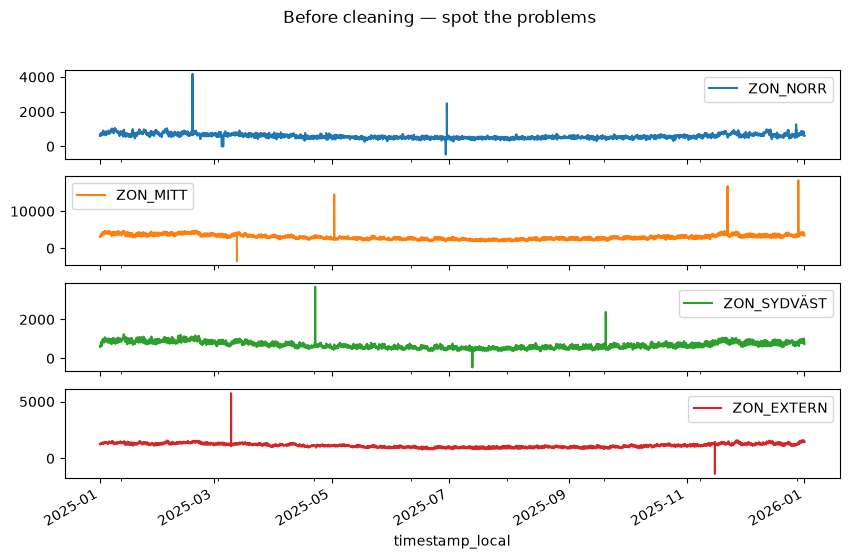

In [5]:
axes = raw[[c for c in raw.columns if c.startswith("ZON_")]].plot(
    subplots=True, figsize=(10, 6), title="Before cleaning — spot the problems");

Negative load, a spike five times anything plausible, and a zone that drops to almost zero for a day — `describe()` and the plot found in seconds what no amount of staring at the CSV would.

## 2. Timestamps first: local time is a trap

The exporter wrote **naive local timestamps** (Europe/Stockholm). Twice a year that goes wrong: the spring DST switch has a missing hour, the autumn switch has the same wall-clock hour **twice**. Repair = localize honestly, convert to UTC, and work in UTC forever after.

`tz_localize("Europe/Stockholm", ...)` attaches a time zone to timestamps that had none. Two keyword arguments handle the two DST accidents: `ambiguous="infer"` sorts the autumn hour that occurs *twice* by order of appearance, and `nonexistent="shift_forward"` moves the spring hour that never happened onto the next valid one. `tz_convert("UTC")` then re-expresses every timestamp in UTC; `df.index.name = "timestamp"` renames the index because the old name promised local time; `sort_index()` puts the rows in time order. **What you see:** `autumn duplicate hour resolved: UTC` — the printed word is the index's time zone, proof the conversion happened.

In [6]:
df = raw.copy()
idx = df.index.tz_localize("Europe/Stockholm", ambiguous="infer", nonexistent="shift_forward")
df.index = idx.tz_convert("UTC")
df.index.name = "timestamp"          # it is not local anymore — say so
df = df.sort_index()
repairs.append("Localized naive Europe/Stockholm timestamps (DST handled), converted to UTC.")
print("autumn duplicate hour resolved:", df.index.tz)

autumn duplicate hour resolved: UTC


`duplicated(keep="first")` marks every repeat of a timestamp except its first occurrence; `~` is *not*, so `df[~...]` keeps the rows that are not repeats. **What you see:** `8760 rows after de-duplication` — a year of hours exactly. The log says 20 dropped, not the 21 counted in section 1: one of the 21 was the autumn DST hour, which the localisation just turned into two different UTC hours. That row was not a duplicate — its timestamp only looked like one because the exporter wrote local time.

In [7]:
dups = df.index.duplicated(keep="first").sum()
df = df[~df.index.duplicated(keep="first")]
repairs.append(f"Dropped {dups} exactly duplicated rows (kept first occurrence).")
print(len(df), "rows after de-duplication")

8760 rows after de-duplication


## 3. The unit glitch

One day of ZON_NORR sits near 0.6 MW in a zone that averages ~600. That is not an outage — it is **a unit error** (GW written as MW). The give-away: the *shape* of the day is perfectly normal, only the magnitude is off by exactly 1000.

Two boolean masks joined with `&` (*both must hold*): a positive value, and a value below 5 % of the column's median. `df.loc[suspect, "ZON_NORR"] *= 1000` multiplies only the masked cells; `set(df.index[suspect].date)` lists the distinct calendar dates among the flagged hours, so you can see whether they cluster — and the log line is built from that list, never typed in by hand: a log must say what the code found. **What you see:** `suspect hours: 24 | all on: [datetime.date(2025, 3, 5)]` — one whole day, every hour, exactly the signature of a unit error and not of an outage.

In [8]:
# Only POSITIVE values can be a GW-as-MW error (they come out ~1000x too
# small). A negative reading is a different fault - leave it to the
# impossible-value step below, or this repair turns -470.7 into -470700.
suspect = (df["ZON_NORR"] > 0) & (df["ZON_NORR"] < df["ZON_NORR"].median() * 0.05)
dates = sorted(set(df.index[suspect].date))          # the distinct calendar dates among the flagged hours
print("suspect hours:", suspect.sum(), "| all on:", dates)
df.loc[suspect, "ZON_NORR"] *= 1000                   # multiply only the flagged cells
repairs.append(f"ZON_NORR {suspect.sum()} h on {', '.join(str(d) for d in dates)}: values x1000 "
               "(GW-as-MW unit error, shape intact).")

suspect hours: 24 | all on: [datetime.date(2025, 3, 5)]


Notice the reasoning in the log entry: we did not just "fix an outlier" — we identified a *mechanism* (unit error) and repaired it losslessly. That is the difference between cleaning and cosmetics.

## 4. Spikes, negatives, gaps

Physically impossible values (negative consumption) and isolated spikes become **missing** — we do not know the true value, so we say so. Then short gaps are interpolated; long gaps stay honest NaN.

### 4.1 The loop, line by line

`for c in zones:` walks the four zone columns. Inside: `df[c] < 0` marks negatives; `rolling(49, center=True, min_periods=12).median()` slides a 49-hour window centred on each hour and takes its median (`min_periods=12` lets the window work near the ends of the series with as few as 12 values); `(df[c] - med).abs() > 4 * df[c].std()` marks values that sit more than four standard deviations from that local median — the spike rule; `|` is *either*; `df.loc[neg | spike, c] = np.nan` blanks both kinds; `if n:` treats a nonzero count as true, so a zone with nothing to report gets no log line. One honest note on the rule: `df[c].std()` is one number for the whole *dirty* column, inflated by the very spikes it hunts, so the rule is lenient — it still catches the gross spikes in this file (5, 4, 3, 2 per zone), and a stricter, spike-proof yardstick (a robust spread measure) is a refinement for later, not today.

Then the gaps. The comments in the cell name the trap — `interpolate(limit=3)` fills the first three hours of *every* gap, however long — and the three lines that measure gaps first: `notna().cumsum()` gives every hour of one gap the same number, `groupby(...).transform("sum")` writes each gap's length onto its own hours, and only gaps of at most `MAX_GAP_H` hours are filled, `limit_area="inside"` keeping the fill between two real values. Last, `sum(axis=1, min_count=len(zones))` recomputes the total across the four zones per row (`axis=1` = across columns) and refuses to sum a row with any zone missing.

Those three gap lines are new pandas — here they are on a toy series, so you can see what each produces before trusting them on 8760 rows:

```
value:    5    NaN  NaN  7    NaN  NaN  NaN  NaN  9
notna():  T    F    F    T    F    F    F    F    T
cumsum(): 1    1    1    2    2    2    2    2    3     <- gap_id: every hour of one gap shares a number
gap_len:  0    2    2    0    4    4    4    4    0     <- isna().groupby(gap_id).transform("sum")
```

`groupby(gap_id)` collects the rows with the same number; `.transform("sum")` adds up the `isna()` flags per group *and writes the group's total back onto each of its rows*, so `gap_len` is as long as the series. With `MAX_GAP_H = 3` the two-hour gap is filled and the four-hour gap stays. Run the next cell and then, if you like, paste this toy series into a scratch cell and try it.

**What you see:** four zeros — no missing values remain in the zone columns, because every gap in this file is short enough to bridge. The repairs log (section 8) will say `538 of 538 missing values interpolated`.

In [9]:
zones = [c for c in df.columns if c.startswith("ZON_")]
# Per zone: flag physically impossible values (negative load) and statistical
# spikes (further from the 49 h rolling median than 4 standard deviations),
# then turn BOTH into NaN — we do not know the true value, so we say so.
for c in zones:
    neg = df[c] < 0
    med = df[c].rolling(49, center=True, min_periods=12).median()
    spike = (df[c] - med).abs() > 4 * df[c].std()
    n = (neg | spike).sum()
    df.loc[neg | spike, c] = np.nan
    if n: repairs.append(f"{c}: {n} impossible/spike values set to NaN.")
gaps_before = df[zones].isna().sum().sum()
# Trap: interpolate(limit=3) does NOT mean "bridge gaps up to 3 h". It fills the
# first 3 missing values of EVERY gap, however long - a 72 h outage would come
# back with its first three hours invented. So measure each gap first, and only
# fill the ones that are short enough to bridge.
MAX_GAP_H = 3
for c in zones:
    gap_id = df[c].notna().cumsum()                              # same number for every hour of one gap
    gap_len = df[c].isna().groupby(gap_id).transform("sum")      # that gap's length, on each of its hours
    short_gap = df[c].isna() & (gap_len <= MAX_GAP_H)
    # limit_area="inside": fill only between two real values, never past the ends
    df.loc[short_gap, c] = df[c].interpolate(limit_area="inside")[short_gap]
repairs.append(f"Zone columns: {gaps_before - df[zones].isna().sum().sum()} of {gaps_before} "
               f"missing values interpolated (gaps <= {MAX_GAP_H} h); longer gaps left as NaN.")
# min_count=len(zones): if ANY zone is NaN this hour, the total becomes NaN too —
# incompleteness stays visible instead of quietly summing fewer zones into a
# smaller "total" that looks fine.
df["total_mw"] = df[zones].sum(axis=1, min_count=len(zones)).round(1)
repairs.append("total_mw recomputed from cleaned zones (NaN where any zone is missing).")
print(df[zones].isna().sum())

ZON_NORR       0
ZON_MITT       0
ZON_SYDVÄST    0
ZON_EXTERN     0
dtype: int64


The temperature sensor is a different story. The cell finds out what the gap is instead of asserting it: `df.index[gap].min()` and `.max()` are the first and last missing hour, and the gap is one unbroken block if the hour count equals the span between them plus one (`pd.Timedelta("1h")` is one hour, so dividing the span by it counts hours). The rule from the top of the notebook then decides — three invented days would be fabrication — so the gap stays, and the log says why. **What you see:** `temp_mid gap: 72 hours, 10 Jul 00:00 to 12 Jul 23:00 UTC, one block: True`.

In [10]:
gap = df["temp_mid"].isna()                          # True on the missing hours
first, last = df.index[gap].min(), df.index[gap].max()
hours = int(gap.sum())
consecutive = hours == int((last - first) / pd.Timedelta("1h")) + 1   # one unbroken block?
print(f"temp_mid gap: {hours} hours, {first:%d %b %H:%M} to {last:%d %b %H:%M} UTC, one block: {consecutive}")
repairs.append(f"temp_mid: {hours} h outage ({first:%Y-%m-%d} to {last:%Y-%m-%d}) LEFT AS NaN — inventing "
               "three days of temperature would be fabrication, not repair.")

temp_mid gap: 72 hours, 10 Jul 00:00 to 12 Jul 23:00 UTC, one block: True


## 5. Sanity checks — as code, not as glances

A cleaned dataset should *prove* it is clean. These asserts are the Lecturecise 5 idea applied to data. Here they live in a notebook; in Lab 5 the same promises become pytest tests in `tests/test_pipeline.py`, and *those* run in CI:

Each `assert` is one promise about the cleaned table. Two idioms: `(df[zones].dropna() >= 0).all().all()` — the first `.all()` asks *every row?* per column, the second *every column?*; `df[zones].isna().mean().max() < 0.01` — the share of missing values per column (mean of True/False), then the worst column — must stay under 1 %; and `1.1 < ratio < 1.8`, a chained comparison. **What you see:** `all sanity checks pass`. If one fails, the message names the promise that broke.

In [11]:
assert df.index.is_unique and df.index.is_monotonic_increasing
assert len(df) == 8760, f"expected 8760 hours, got {len(df)}"
assert (df[zones].dropna() >= 0).all().all(), "negative load survived cleaning"
assert df[zones].isna().mean().max() < 0.01, "too much missing data remains"
ratio = df["total_mw"].max() / df["total_mw"].mean()
assert 1.1 < ratio < 1.8, f"peak/mean ratio {ratio:.2f} implausible for zonal load"
print("all sanity checks pass")

all sanity checks pass


One thing the clean series makes easy — **resampling**. The rule from the lecture: **power (MW) averages, energy (MWh) sums.** A daily *mean* of MW is average power and means something; a daily *sum* of MW is not a physical quantity (multiply the mean by 24 h if you want energy). And for security work it is often the daily **peak** that matters:

`.resample("1D")` bins the hourly series into days; `.agg(["max", "mean"])` computes both statistics per bin at once and returns two columns, renamed on the next line. **What you see:** the plot of the two curves over the year (peak always above mean), and the first five rows: 1 January peaks at 6790.6 MW with a mean of 6112.4 MW. The index is still UTC, midnight per day.

,peak_mw,mean_mw
timestamp,,
2025-01-01 00:00:00+00:00,6790.6,6112.387500
2025-01-02 00:00:00+00:00,7616.0,7029.491667
2025-01-03 00:00:00+00:00,7913.2,7360.316667
2025-01-04 00:00:00+00:00,7643.2,7179.045833
2025-01-05 00:00:00+00:00,7967.2,7309.279167


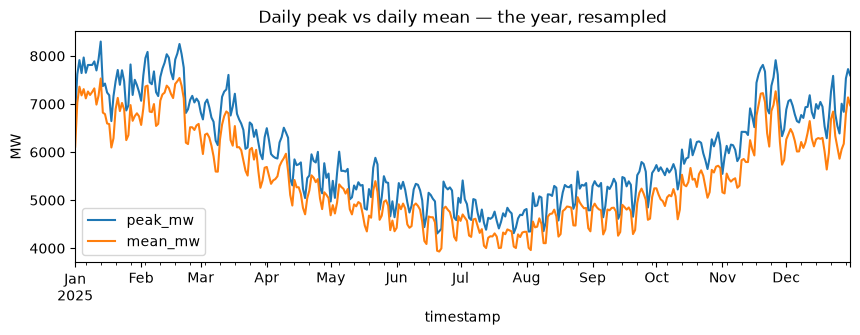

In [12]:
# Resample the cleaned total to one row per day.
#   .max()  -> the daily PEAK (what security screening cares about)
#   .mean() -> the average power that day (a legitimate statistic for MW)
# .sum() would add 24 MW readings — that is not energy; use mean()*24 for MWh.
daily = df["total_mw"].resample("1D").agg(["max", "mean"])
daily.columns = ["peak_mw", "mean_mw"]
ax = daily.plot(figsize=(10, 3), title="Daily peak vs daily mean — the year, resampled")
ax.set_ylabel("MW")
daily.head()

## 6. Store it properly: Parquet + DuckDB

CSV was the delivery format; it is not an analysis format. **Parquet** keeps types, compresses, loads in milliseconds. **DuckDB** puts SQL on top of it — no server, one file, made for exactly this.

SQL in one breath, since this is the course's first query: `SELECT` *what columns*, `FROM` *which table*, `WHERE` *which rows*, `GROUP BY` *one row per what*, `ORDER BY` *sorted how*. Everything below is those five words in that order.

### 6.1 Write, then query

`to_parquet` writes the cleaned table; `duckdb.connect("svedala.duckdb")` creates the database file and hands back a connection; the first `execute` runs SQL that reads the Parquet file straight into a table named `hourly`. The second `execute` is the query: `date_trunc('day', ...)` cuts each timestamp down to its day, `max(total_mw)` takes the highest value per group, `GROUP BY day` makes the groups, `.df()` hands the answer back as a pandas table. The comments name the time-zone trap: which clock a "day" starts on is a choice, and we say UTC twice — in the truncation and in the bounds.

**What you see:** seven rows, one per day from 13 to 19 January, peaks between about 6600 and 8300 MW; Monday the 13th is the week's highest at 8299.1 MW.

In [13]:
df.to_parquet("svedala_hourly_clean.parquet")
import duckdb
con = duckdb.connect("svedala.duckdb")
con.execute("CREATE OR REPLACE TABLE hourly AS SELECT * FROM 'svedala_hourly_clean.parquet'")
# Trap: the timestamps carry a time zone, and DuckDB truncates them to days in
# YOUR MACHINE's time zone unless told otherwise - a laptop in Stockholm and one
# in Helsinki would get different days and possibly different peaks. Say which
# clock you mean; the data is UTC, so ask for UTC days - and give the date
# bounds a zone too (the +00), or they are read in the machine's zone as well.
con.execute("""
    SELECT date_trunc('day', timestamp AT TIME ZONE 'UTC') AS day,
           max(total_mw) AS peak_mw
    FROM hourly
    WHERE timestamp >= '2025-01-13 00:00:00+00' AND timestamp < '2025-01-20 00:00:00+00'
    GROUP BY day ORDER BY day
""").df()

,day,peak_mw
0,2025-01-13,8299.1
1,2025-01-14,7372.4
2,2025-01-15,7425.2
3,2025-01-16,7238.9
4,2025-01-17,7181.7
5,2025-01-18,6644.4
6,2025-01-19,7162.2


## 7. Sidebar: two data-quality stories you already know

Cleaning is not only about time series. The Svedala *network* data carries the same lessons: the line current limits (`max_i_ka`) are **empty** in the source — every loading percentage you have ever computed rests on defaults we chose and documented. And look at the transformer ratings:

`nsmallest(5, "sn_mva")` returns the five rows with the smallest rated power. **What you see:** five transformers at exactly 100.0 MVA, all on the 400 kV side — read the next paragraph for why that number cannot be real.

In [14]:
t = pd.read_csv("../data/svedala/transformers.csv", index_col=0)
t[["name", "sn_mva", "vn_hv_kv", "vn_lv_kv"]].nsmallest(5, "sn_mva")

,name,sn_mva,vn_hv_kv,vn_lv_kv
0,FT63_T12,100.0,400.0,20.0
6,CT11_T2,100.0,400.0,17.0
8,FT47_T11,100.0,400.0,20.0
11,FT44_T12,100.0,400.0,20.0
12,FT50_T402,100.0,400.0,135.0


100 MVA nameplates on 400 kV step-up transformers that carry hundreds of MW — **placeholder values**, not engineering. This is why the course's security criterion counts *line* loadings only, and why every dataset you publish needs a README that says what can and cannot be trusted. Data quality is not a preprocessing step; it is a property you must establish before any result downstream means anything.

## 8. The repairs log — read it back

This list is the seed of a habit: in Period 2, `DECISIONS.md` plays exactly this role for your whole project.

`enumerate(repairs, 1)` walks the list and hands out a running number starting at 1; `f"{i:2d}"` prints that number two characters wide so the list lines up. **What you see:** ten numbered sentences, in the order the repairs were made — the DST fix, 20 duplicates, the unit error, the four spike counts (5, 4, 3, 2), the 538 bridged hours, the recomputed total and the 72-hour gap left alone. Every one names a mechanism, not just an action.

In [15]:
for i, r in enumerate(repairs, 1):
    print(f"{i:2d}. {r}")

 1. Localized naive Europe/Stockholm timestamps (DST handled), converted to UTC.
 2. Dropped 20 exactly duplicated rows (kept first occurrence).
 3. ZON_NORR 24 h on 2025-03-05: values x1000 (GW-as-MW unit error, shape intact).
 4. ZON_NORR: 5 impossible/spike values set to NaN.
 5. ZON_MITT: 4 impossible/spike values set to NaN.
 6. ZON_SYDVÄST: 3 impossible/spike values set to NaN.
 7. ZON_EXTERN: 2 impossible/spike values set to NaN.
 8. Zone columns: 538 of 538 missing values interpolated (gaps <= 3 h); longer gaps left as NaN.
 9. total_mw recomputed from cleaned zones (NaN where any zone is missing).
10. temp_mid: 72 h outage (2025-07-10 to 2025-07-12) LEFT AS NaN — inventing three days of temperature would be fabrication, not repair.


## Self-check

`np.isclose(a, b, rtol=0.02)` compares two tables cell by cell within 2 %, giving True/False per cell; `.mean()` of that is the share that agree. `ref.loc[common.index, zones]` picks the reference rows at exactly the timestamps you kept (`common` drops the rows with any missing zone). **What you see:** `ALL OK — cleaned data matches the reference on 100% of cells.` and a second line saying the repaired hours agree too. Anything below 97 % would mean a repair went wrong somewhere; the assert says so. (Yes, the clean reference sat next to the dirty file all along — real data has no answer key; this exercise does, so you can check your judgment.)

In [16]:
ref = pd.read_parquet("../data/svedala-year/svedala_hourly.parquet")
common = df[zones].dropna()
match = (np.isclose(common, ref.loc[common.index, zones], rtol=0.02)).mean()
assert match > 0.97, f"cleaned data matches reference on only {match:.0%} of cells"
print(f"ALL OK — cleaned data matches the reference on {match:.0%} of cells.")
if round(match, 2) < 1:      # same rounding as the printed percentage
    print("(The rest are the hours you repaired — compare a few and judge your repairs.)")
else:
    print("(Every repaired hour agrees with the reference within 2 % — the repairs were the right ones.)")

ALL OK — cleaned data matches the reference on 100% of cells.
(Every repaired hour agrees with the reference within 2 % — the repairs were the right ones.)


## 9. What you take to Lab 5

Lab 5 asks for this notebook's method as toolbox code: `clean_load(series)` returning the cleaned series *and* the repairs list, with the rules named as constants (like `MAX_GAP_H = 3` above) and the gap-length idiom from section 4 — plus `store` writing Parquet and registering it in DuckDB, as in section 6. The tests you write there are section 5's asserts, one per promise.